In [2]:
import numpy as np
import lightkurve as lk 
import matplotlib.pyplot as plt 
%matplotlib inline

In [3]:
# From Animation70
def getData(ra:float, dec:float, sectorno:int):
    location = str(ra) + ", " + str(dec)
    search_result = lk.search_tesscut(location, sector=sectorno)
    tpf = search_result.download(cutout_size=60)
    return tpf
    
#getData(356, -3, 70)

In [4]:
lower_tpf = getData(356.7, -2.795, 70)
middle_tpf = getData(356.4, -2.9, 70)
upper_tpf = getData(356.2, -3.025, 70)

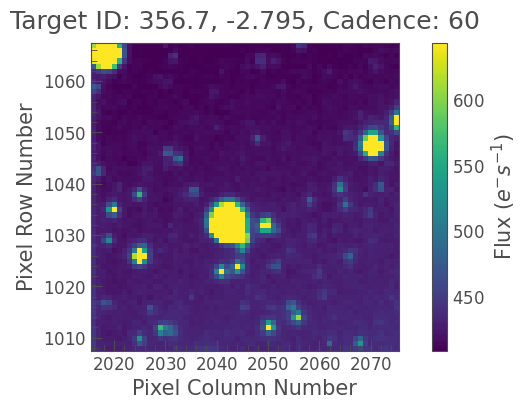

In [6]:
lower_tpf.plot(frame=60)
%matplotlib inline

In [8]:
#check how many usable pixels there are
postage_stamp_mask = lower_tpf.hdu[2].data > 0
postage_stamp_mask.sum()

3600

In [9]:
lc_raw = lower_tpf.to_lightcurve(aperture_mask='all')
_, spurious_cadences = lc_raw.flatten().remove_outliers(return_mask=True)
lc_clean = lc_raw[~spurious_cadences]

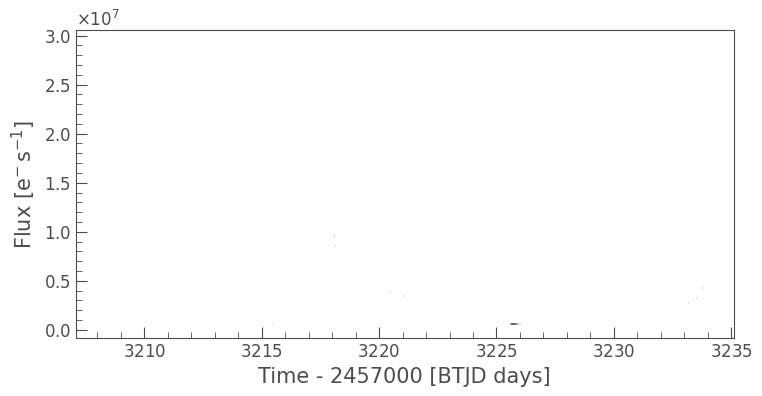

In [10]:
lc_clean.errorbar(alpha=0.5, normalize=False);

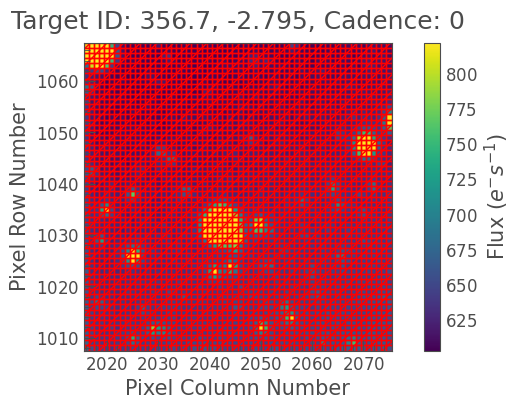

In [12]:
lower_tpf.plot(aperture_mask='all');

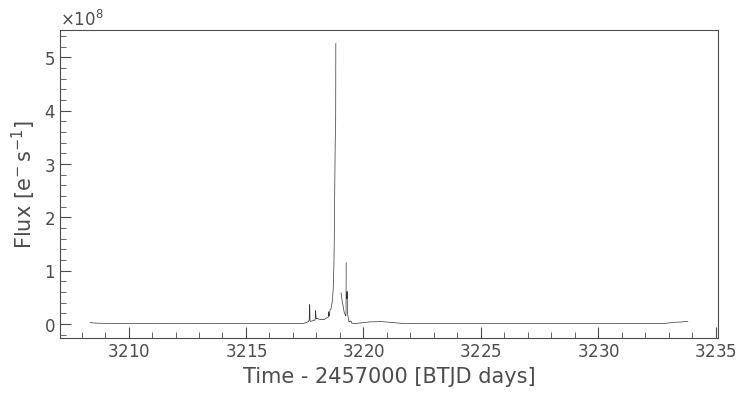

In [14]:
lower_lc = lower_tpf.to_lightcurve(aperture_mask="all")
lower_lc.plot();

C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=7.35e+05 electron / s +/- 1.81e+07 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(
C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=1.74e+02 electron / s +/- 4.57e+03 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(


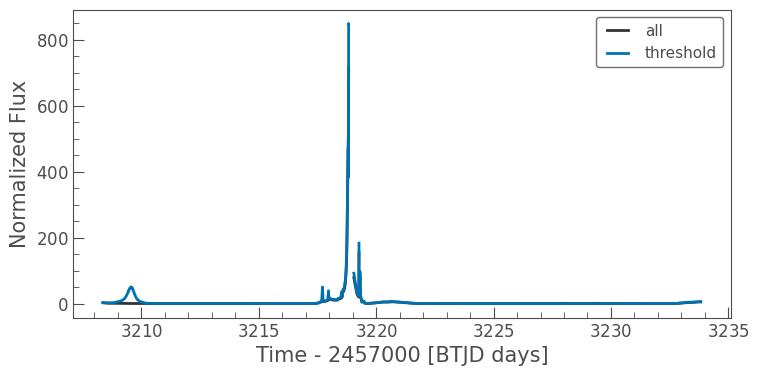

In [16]:
#threshold lc
ax = lower_tpf.to_lightcurve(aperture_mask='all').normalize().plot(label='all', linewidth=2);
lower_tpf.to_lightcurve(aperture_mask='threshold').normalize().plot(ax=ax, label='threshold', linewidth=2);

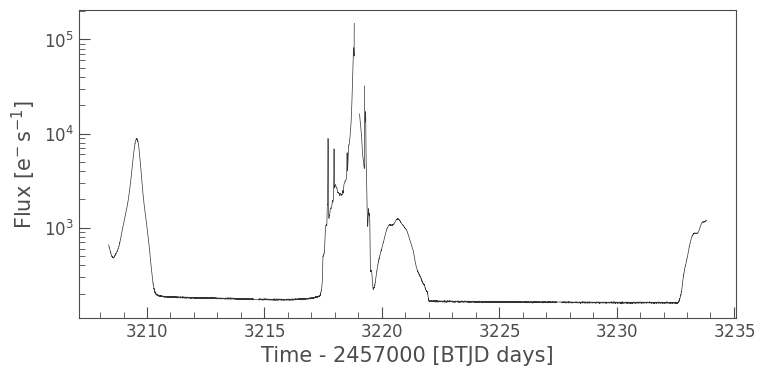

In [34]:
lower_lc = lower_tpf.to_lightcurve(aperture_mask="threshold")
lower_lc.plot()
plt.yscale('log') 
plt.show()

In [19]:
# Example function to create a light curve with a custom threshold
def create_lightcurve_with_threshold(tpf, threshold):
    # Create a threshold mask with the specified threshold
    aperture_mask = tpf.create_threshold_mask(threshold=threshold)
    
    # Convert the TPF to a light curve using the threshold aperture mask
    lightcurve = tpf.to_lightcurve(aperture_mask=aperture_mask)
    
    return lightcurve

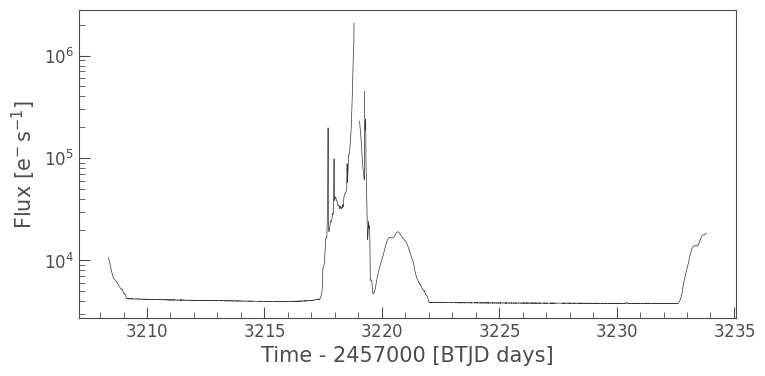

In [22]:
lower_lc_threshold = create_lightcurve_with_threshold(lower_tpf, 10)
lower_lc_threshold.plot()
plt.yscale('log') 
plt.show()

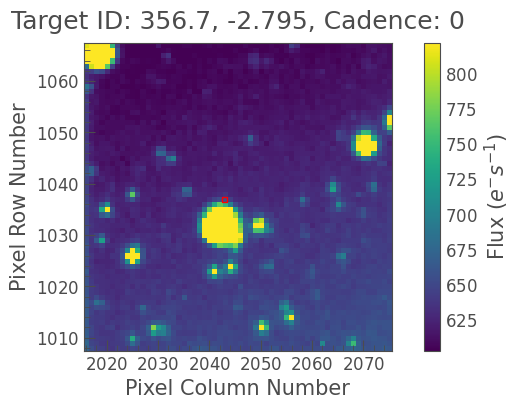

In [23]:
lower_tpf.plot(aperture_mask='threshold');

In [32]:
def plot_tpf_with_custom_threshold(tpf, threshold):
    # Create a threshold mask with the specified threshold
    aperture_mask = tpf.create_threshold_mask(threshold=threshold)
    
    # Plot the TPF with the custom threshold mask
    tpf.plot(aperture_mask=aperture_mask)
    plt.title('')
    plt.xlabel('')
    plt.ylabel('')
    
    # Customizing the plot appearance
    fig = plt.gcf()
    fig.set_facecolor('black')    
    
    ax = plt.gca()
    ax.tick_params(axis='y', colors='white')

    # Example for a plot with no x-axis
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='x', direction='in', pad=-20)  # Adjust font size with labelsize 

    # Access the color bar created by tpf.plot()
    im = ax.get_images()[0]
    cbar = im.colorbar
    for label in cbar.ax.get_yticklabels():
        label.set_color('white')
    cbar.ax.set_ylabel("Flux (e$^{-}$s$^{-1}$)", color='white')
    
    # Shrink and position the color bar
    height = 0.6
    bottom = (1 - height) / 2
    cbar.ax.set_position([0.76, bottom, 0.02, height])
    
    plt.show()

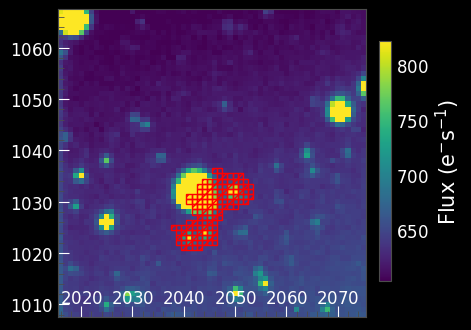

In [33]:
plot_tpf_with_custom_threshold(lower_tpf, 1)

In [12]:
lower_tpf[0:4000].interact() #ask malena about the moving thing!!

C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=1.47e+05 electron / s +/- 2.96e+06 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(
C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=1.47e+05 electron / s +/- 6.49e+05 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(


(1.505, 1.525)

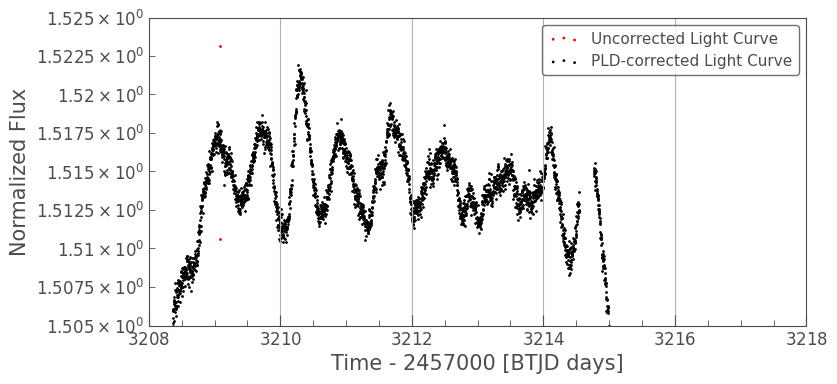

In [23]:
# PLD Correction

#HOW TH DO YOU CONVERT BETWEEN LIGHTCURVES AND TPFS?

#pld_lc = lk.read("C:/Users/ktp9/Documents/TESSNeptune24/Lightcurves/TESS_356.7, -2.795_custom-lc.fits")
#pld_lc.plot();

from lightkurve.correctors import PLDCorrector
from matplotlib.pyplot import figure

lower_pld = PLDCorrector(lower_tpf, aperture_mask = lower_aperture)
lower_corrected = lower_pld.correct(background_aperture_mask = background_aperture)

# Create and plot an uncorrected light curve using Simple Aperture Photometry
lower_uncorrected = lower_tpf.to_lightcurve(aperture_mask = lower_aperture)
ax = lower_uncorrected.normalize().scatter(color='red', label='Uncorrected Light Curve');
# Plot the PLD-corrected light curve in black on top
lower_corrected.normalize().remove_outliers().scatter(ax=ax, color='black', label='PLD-corrected Light Curve');
plt.yscale('log') 
plt.grid()
ax.set_xlim([3208, 3218])
ax.set_ylim([1.505, 1.525])

In [6]:
#BYO Aperture Function
import numpy as np

def homemadeAperture(dimensions, x1, x2, y1, y2):
    """
    Create a boolean array with specified dimensions, setting a rectangular area to True.
    
    Parameters:
    dimensions (tuple): The dimensions of the array (rows, cols).
    x1 (int): The starting x-coordinate (column) of the rectangle.
    x2 (int): The ending x-coordinate (column) of the rectangle.
    y1 (int): The starting y-coordinate (row) of the rectangle.
    y2 (int): The ending y-coordinate (row) of the rectangle.
    
    Returns:
    np.ndarray: A boolean array with True in the specified rectangle and False elsewhere.
    """
    # Initialize the array with False
    array = np.zeros(dimensions, dtype=bool)
    
    # Set the specified rectangular area to True
    array[y1:y2+1, x1:x2+1] = True
    
    return array

In [7]:
##PLD Correction Function

from lightkurve.correctors import PLDCorrector
from matplotlib.pyplot import figure

def applyPLD(tpf, aperture, bg_aperture, scale, x_min, x_max, y_min, y_max):
    pld = PLDCorrector(tpf, aperture_mask = aperture)
    corrected = pld.correct(background_aperture_mask = bg_aperture)
    pld.diagnose_masks();

    # Create and plot an uncorrected light curve using Simple Aperture Photometry
    uncorrected = tpf.to_lightcurve(aperture_mask = aperture)
    ax = uncorrected.normalize().scatter(color='red', label='Uncorrected Light Curve');
    # Plot the PLD-corrected light curve in black on top
    corrected.normalize().remove_outliers().scatter(ax=ax, color='black', label='PLD-corrected Light Curve');
    plt.yscale(scale) 
    plt.grid()
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

    pld.diagnose();

In [8]:
#Making custom apertures for all sections

dimensions = (60, 60)
full_aperture = homemadeAperture(dimensions, 0, 60, 0, 60)
lower_aperture = homemadeAperture(dimensions, 15, 35 - 4, 10 + 9, 60)
lower_bg_aperture = homemadeAperture(dimensions, 0, 15, 0, 60) + homemadeAperture(dimensions, 35, 60, 0, 60)
middle_aperture = homemadeAperture(dimensions, 15, 35, 0, 60)
middle_bg_aperture = full_aperture &~middle_aperture
upper_aperture = homemadeAperture(dimensions, 15, 35, 0, 50)
upper_bg_aperture = full_aperture &~upper_aperture

C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=2.47e+05 electron / s +/- 3.86e+06 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(
C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=2.47e+05 electron / s +/- 8.57e+05 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(


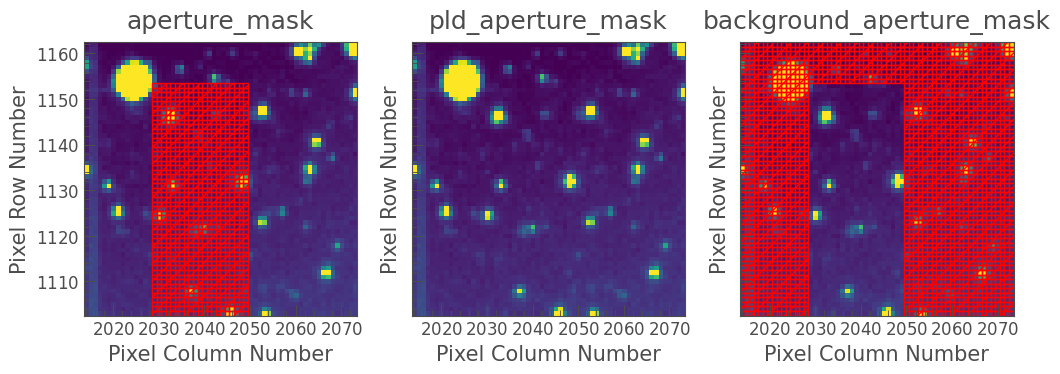

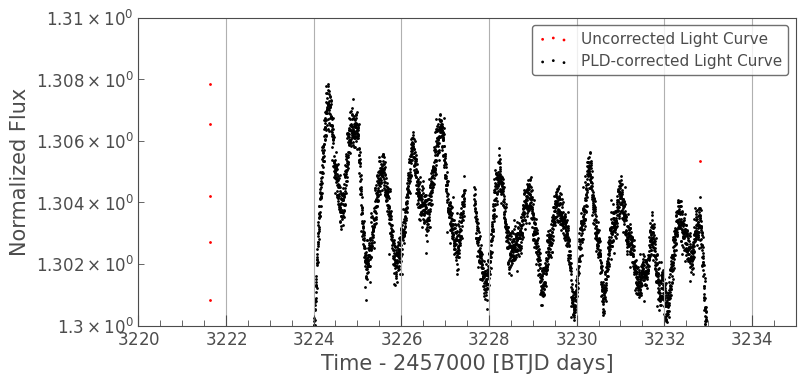

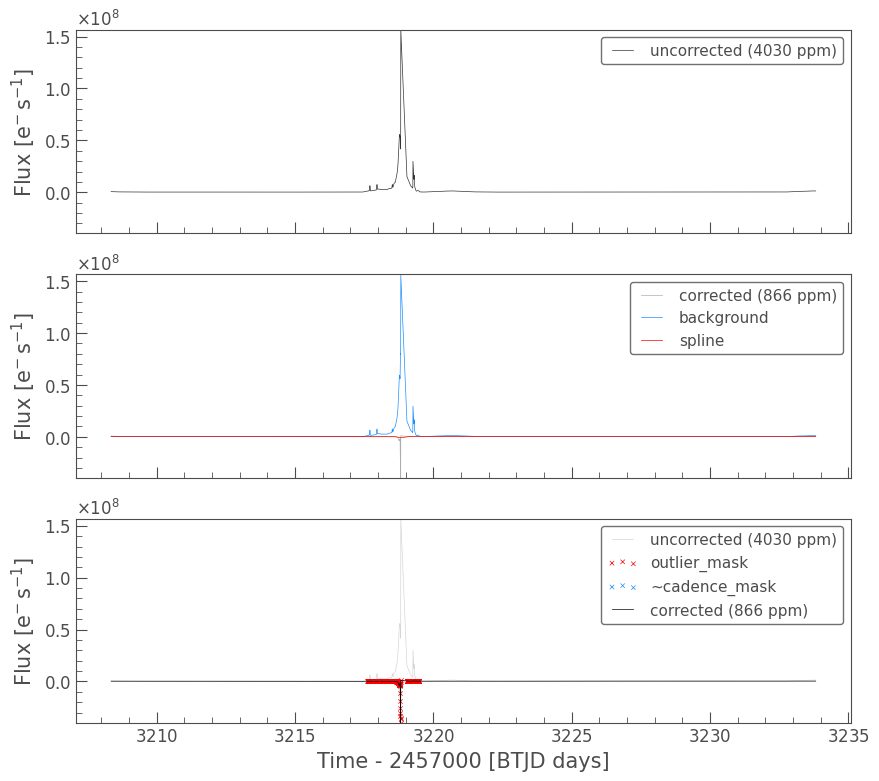

In [47]:
upper_pld = applyPLD(upper_tpf, upper_aperture, upper_bg_aperture, "log", 3220, 3235, 1.3, 1.31)

C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=2.80e+05 electron / s +/- 5.00e+06 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(
C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=2.72e+05 electron / s +/- 6.42e+05 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(


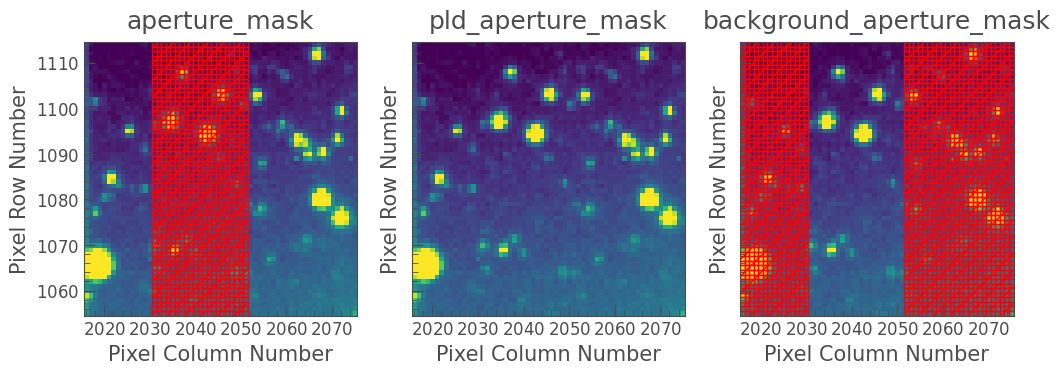

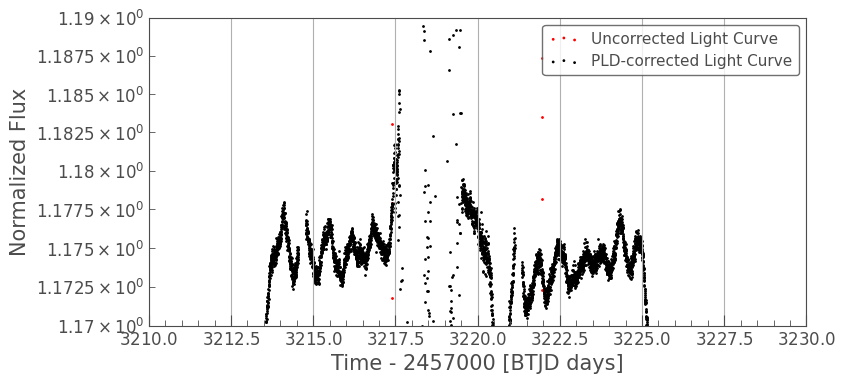

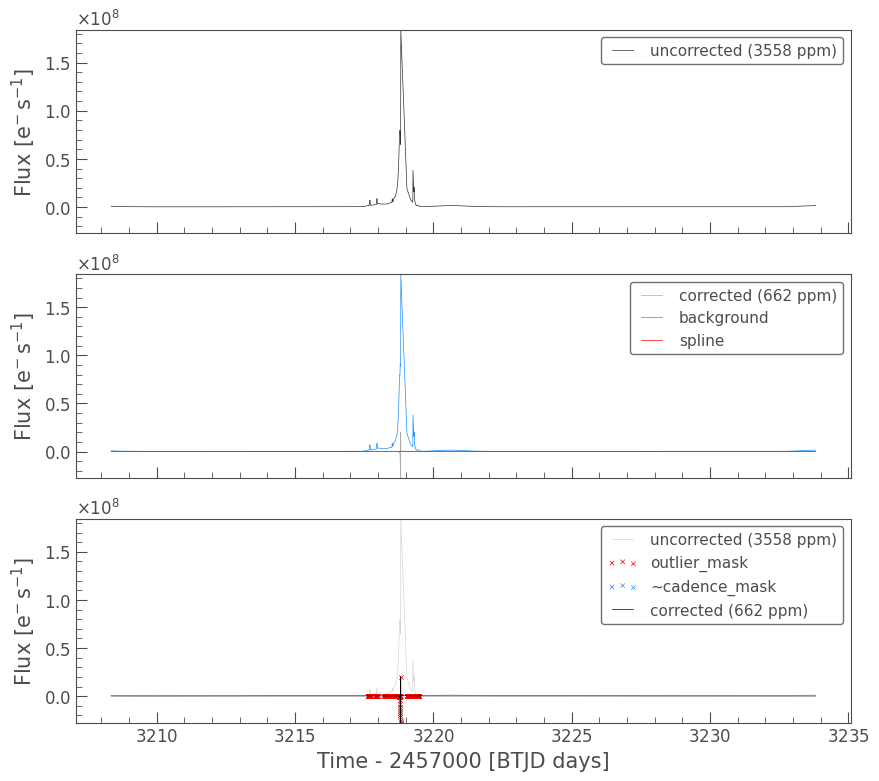

In [40]:
middle_pld = applyPLD(middle_tpf, middle_aperture, middle_bg_aperture, "log", 3210, 3230, 1.17, 1.19)

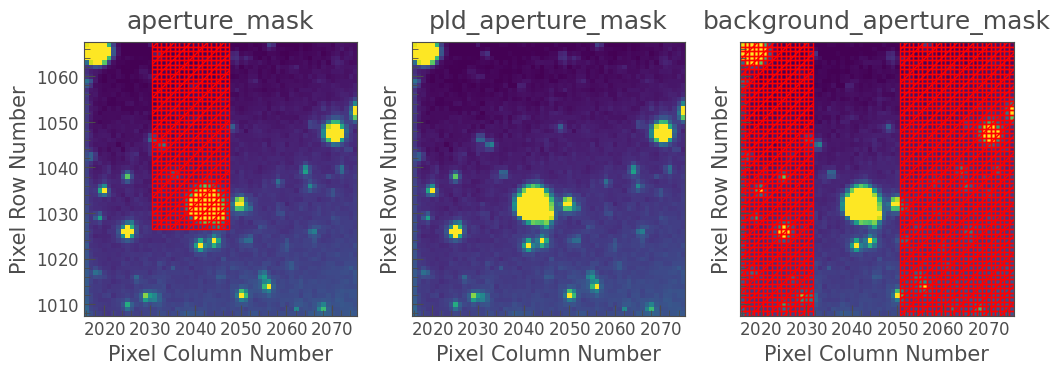

In [24]:
lower_pld.diagnose_masks();

C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=1.47e+05 electron / s +/- 2.96e+06 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(
C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=1.47e+05 electron / s +/- 6.49e+05 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(


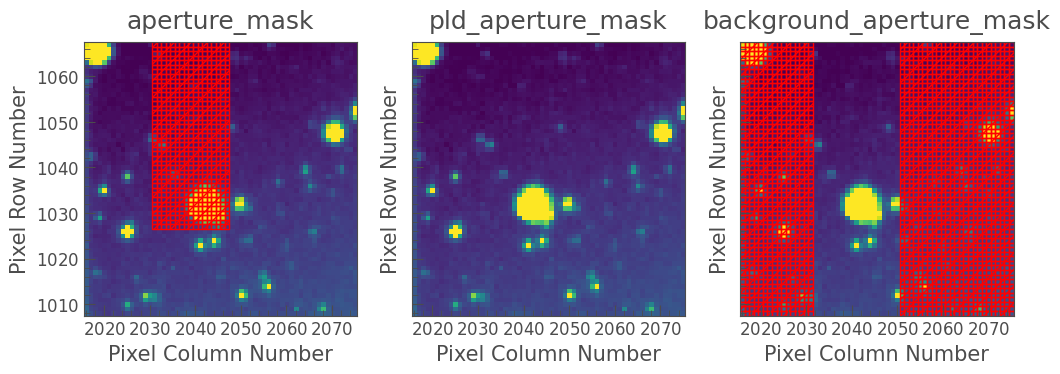

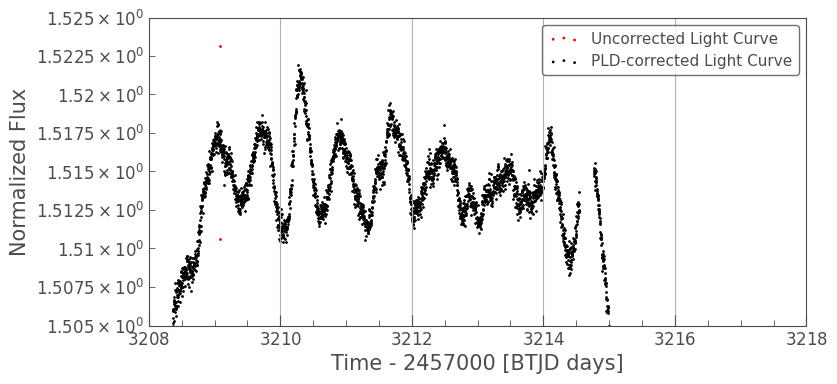

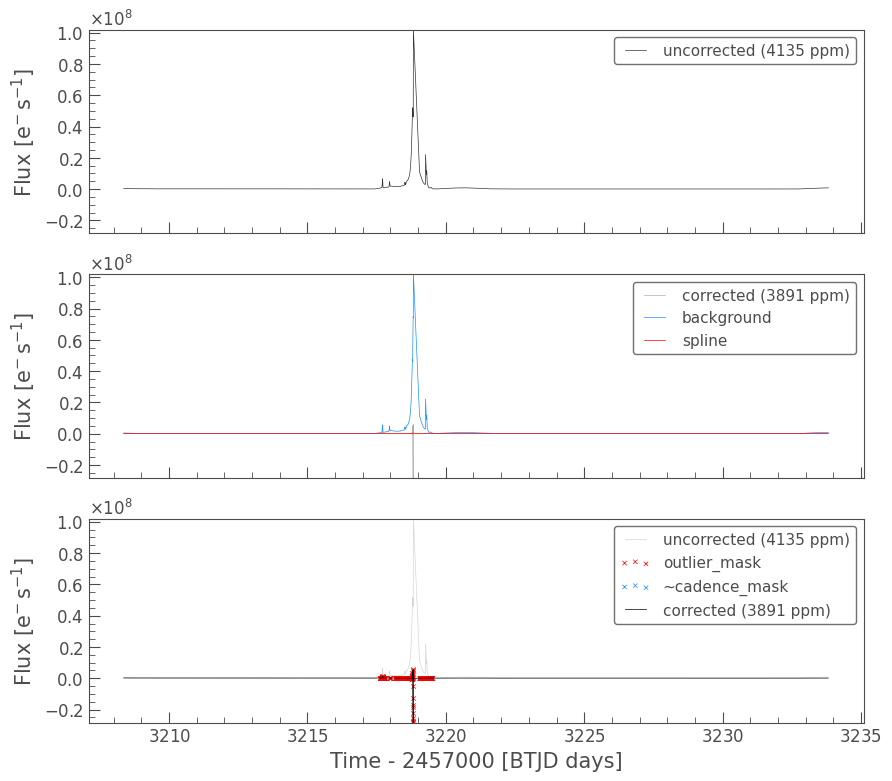

In [31]:
lower_pld = applyPLD(lower_tpf, lower_aperture, lower_bg_aperture, "log", 3208, 3218, 1.505, 1.525)

In [29]:
middle_pld = applyPLD(middle_tpf, middle_aperture, middle_bg_aperture, "log", 3215, 3230, 0, 5)

AttributeError: 'NoneType' object has no attribute 'diagnose'

SyntaxError: invalid syntax (3376796636.py, line 1)

In [109]:
#CBV Noise Suppression

from lightkurve import search_lightcurve
import numpy as numpy
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

lower_preCBV = lower_tpf.to_lightcurve(aperture_mask = lower_aperture)


In [111]:
from lightkurve.correctors import CBVCorrector
cbvCorrector = CBVCorrector(lower_preCBV)

The SingleScale CBVs do not appear to be well aligned to the light curve. Consider using "interpolate_cbvs=True"
The MultiScale CBVs do not appear to be well aligned to the light curve. Consider using "interpolate_cbvs=True"
The MultiScale CBVs do not appear to be well aligned to the light curve. Consider using "interpolate_cbvs=True"
The MultiScale CBVs do not appear to be well aligned to the light curve. Consider using "interpolate_cbvs=True"
The Spike CBVs do not appear to be well aligned to the light curve. Consider using "interpolate_cbvs=True"


In [112]:
cbvCorrector.cbvs

[TESS CBVs, Sector.Camera.CCD : 70.1.1, CBVType : SingleScale, nCBVS : 16,
 TESS CBVs, Sector.Camera.CCD : 70.1.1, CBVType.Band: MultiScale.1, nCBVs : 8,
 TESS CBVs, Sector.Camera.CCD : 70.1.1, CBVType.Band: MultiScale.2, nCBVs : 8,
 TESS CBVs, Sector.Camera.CCD : 70.1.1, CBVType.Band: MultiScale.3, nCBVs : 4,
 TESS CBVs, Sector.Camera.CCD : 70.1.1, CBVType : Spike, nCBVS : 7]

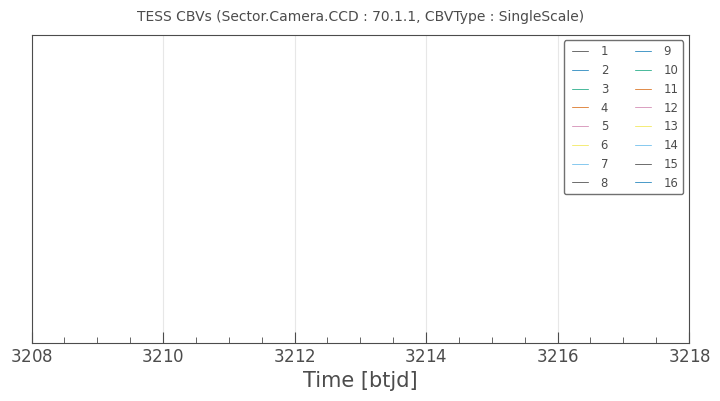

In [115]:
cbvCorrector.cbvs[0].plot();
cbvax = plt.gca()
cbvax.set_xlim(3208, 3218)
%matplotlib inline #table this

In [120]:
# RAHHH LINEAR REGRESSION SCATTERED LIGHT REMOVAL

import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: title={'center': 'Target ID: 356.7, -2.795, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

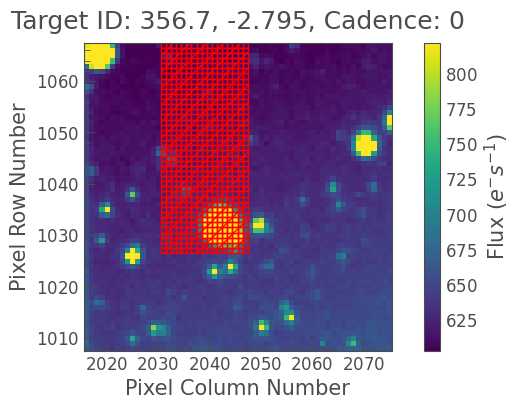

In [122]:
lower_tpf = getData(356.7, -2.795, 70)
lower_tpf.plot(aperture_mask = lower_aperture)

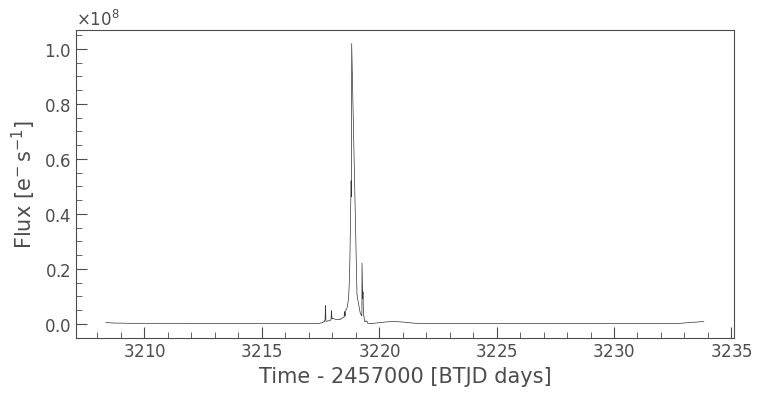

In [163]:
lower_uncorrected_lr = lower_tpf.to_lightcurve(aperture_mask=lower_aperture)
lower_uncorrected_lr = lower_uncorrected_lr.remove_nans()
lower_uncorrected_lr.plot();

In [152]:
regressors = lower_tpf.flux[:, ~lower_aperture]
regressors.shape

(10716, 2903)

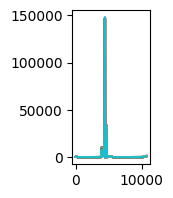

In [153]:
plt.plot(regressors[:, :30]);

In [154]:
from lightkurve.correctors import DesignMatrix
dm = DesignMatrix(regressors, name='regressors')

In [155]:
dm

regressors DesignMatrix (10716, 2903)

In [156]:
dm = dm.pca(5)
dm

regressors DesignMatrix (10716, 5)

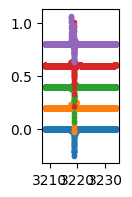

In [157]:
plt.plot(lower_tpf.time.value, dm.values + np.arange(5)*0.2, '.');


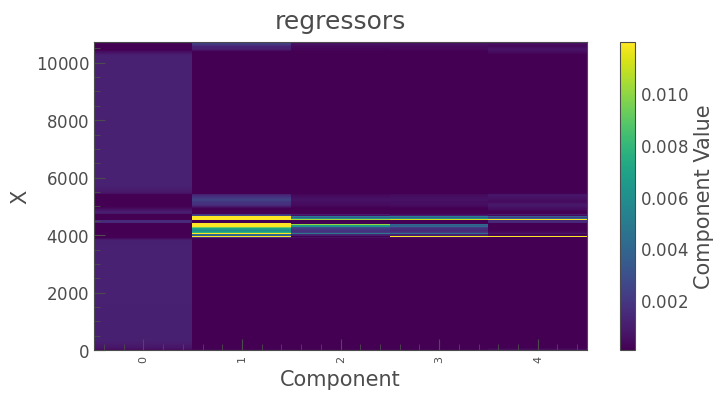

In [158]:
dm.plot();

In [159]:
dm = dm.append_constant()

In [164]:
#removing the bg w/ lr

from lightkurve.correctors import RegressionCorrector
lr_corrector = RegressionCorrector(lower_uncorrected_lr)
lr_corrector

RegressionCorrector (ID: 356.7, -2.795)

In [165]:
lower_lr_corrected = lr_corrector.correct(dm)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 10716 but corresponding boolean dimension is 10611

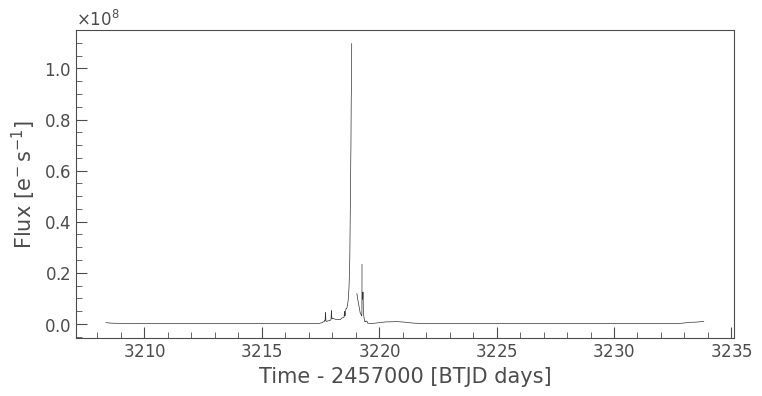

In [10]:
# Lightcurve of a few background pixels

dimensions = (60, 60)
bg_pixels = homemadeAperture(dimensions, 12, 60, 51, 60) + homemadeAperture(dimensions, 40, 60, 20, 35)

uncorrected_bg = lower_tpf.to_lightcurve(aperture_mask=bg_pixels)
uncorrected_bg.plot();
%matplotlib inline

C:\Users\ktp9\AppData\Local\anaconda3\envs\Neptune24\Lib\site-packages\lightkurve\lightcurve.py:1131: LightkurveWarning: The light curve appears to be zero-centered (median=1.27e+05 electron / s +/- 4.19e+06 electron / s); `normalize()` will divide the light curve by a value close to zero, which is probably not what you want.
  warnings.warn(


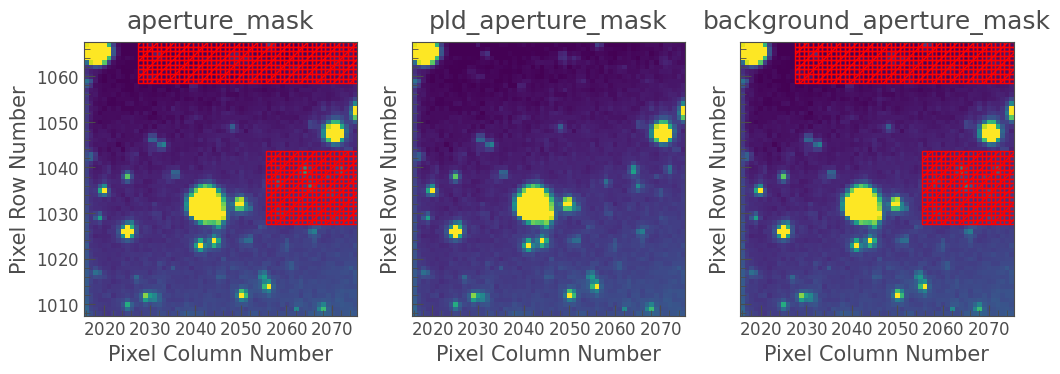

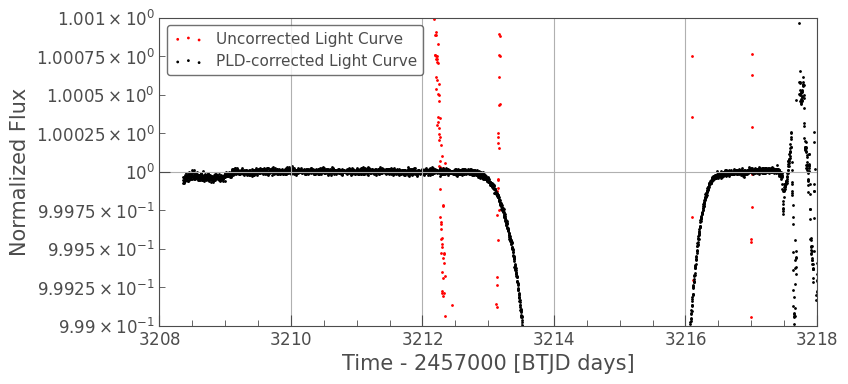

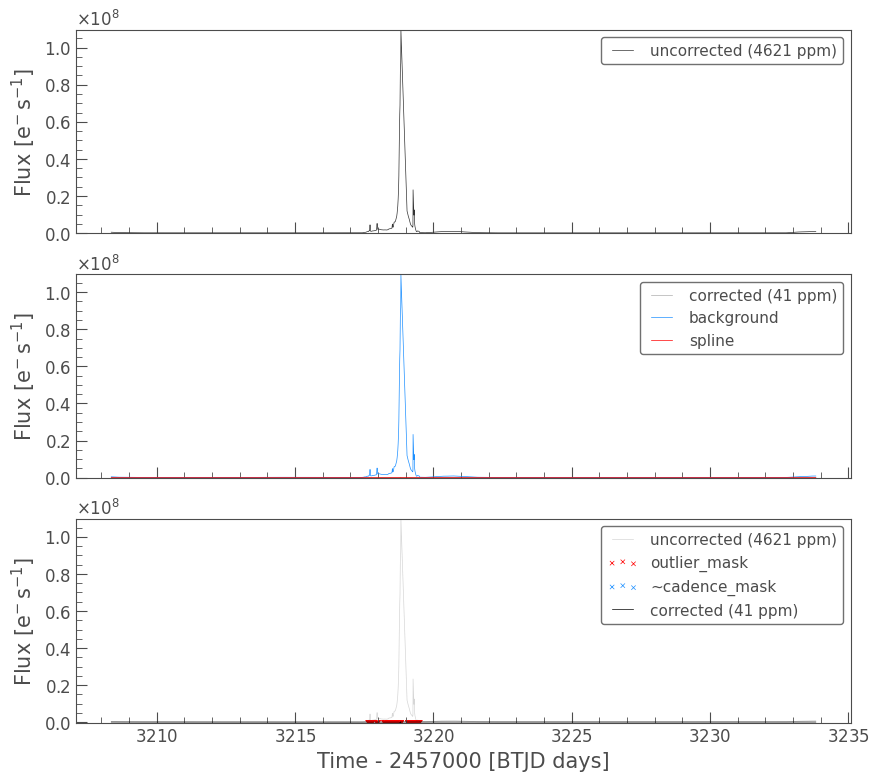

In [21]:
bg_pld = applyPLD(lower_tpf, bg_pixels, bg_pixels, "log", 3208, 3218, 0.999, 1.001)